In [62]:
import numpy as np
import emcee
from scipy.stats import norm
from astropy.io import fits

In [63]:
flux = fits.open('n0044_HIP55192_ts23_2020may20_spectrum.fits')[0].data
lam = fits.open('ts23_2020may20_thar_solution_wavearr.fits')[0].data

In [76]:
mask = (lam > 6704) & (lam < 6710)

lam = lam[mask]
flux = flux[mask]

In [77]:
flux = flux / np.median(flux)

flux /= np.median(flux)

#Error from noise estimation from continuum
cont_mask = (lam > 6705.2) & (lam < 6708.6)
noise = np.std(flux[cont_mask])

flux_err = np.full_like(flux, noise)

In [78]:
flux = flux / np.median(flux)
flux_err = flux_err / np.median(flux)

In [79]:
#"We bring the spectrum to the approximate rest frame using Gaia radial velocity and apply barycentric correction"
c = 299792.458  
rv = 13.0 #rv from MOCA

lam = lam / (1 + rv / c)

In [80]:
def model(theta, lam):
    m, b, C1, C2, sigma, RVs = theta
    
    lambda_Li = 6707.819 
    lambda_ref = 6705.1   
    
    continuum = m * lam + b
    
    li_line = C1 * np.exp(-0.5 * ((lam - (lambda_Li + RVs)) / sigma)**2)
    ref_line = C2 * np.exp(-0.5 * ((lam - (lambda_ref + RVs)) / sigma)**2)
    
    return continuum + li_line + ref_line

In [81]:
def log_likelihood(theta, lam, flux, flux_err):
    model_flux = model(theta, lam)
    return -0.5 * np.sum(((flux - model_flux) / flux_err)**2)

In [82]:
def log_prior(theta):
    m, b, C1, C2, sigma, RVs = theta
        
    if (-0.02 < m < 0.02 and
        0.95 < b < 1.05 and
        -1.0 < C1 < 0.0 and   # Li absorption
        -1.0 < C2 < 0.0 and   # Reference absorption
        0.02 < sigma < 0.3 and
        -0.5 < RVs < 0.5):
        return 0.0
    
    return -np.inf

In [83]:
def log_probability(theta, lam, flux, flux_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, lam, flux, flux_err)

In [84]:
def compute_ew(samples):
    m, b, C1, _, sigma, _ = samples.T
    
    lambda_Li = 6707.819
    
    
    area = np.sqrt(2 * np.pi) * sigma * np.abs(C1)
    
  
    H = m * lambda_Li + b
    
    EW = area / H
    
    return EW

In [85]:
def fit_lithium_EW(lam, flux, flux_err, nwalkers=100, nsteps=5000):
    
   
    initial = np.array([0.0, 1.0, -0.1, -0.1, 0.1, 0.0])
    ndim = len(initial)
    
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability,
        args=(lam, flux, flux_err)
    )
    
    sampler.run_mcmc(pos, nsteps, progress=True)
    

    flat_samples = sampler.get_chain(discard=2000, thin=10, flat=True)
    

    EW_samples = compute_ew(flat_samples)
    
    EW_median = np.median(EW_samples)
    EW_std = np.std(EW_samples)
    
    return EW_median * 1000, EW_std * 1000, EW_samples * 1000, flat_samples

In [86]:
EW, EW_err, EW_samples, samples = fit_lithium_EW(lam, flux, flux_err)

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:25<00:00, 193.26it/s]


EW = 84.74 ± 22.99 mÅ


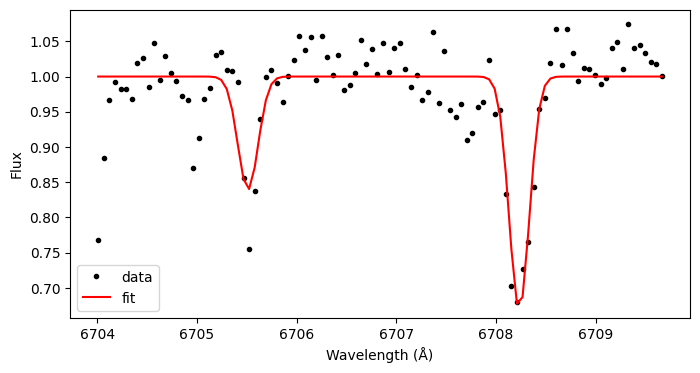

In [87]:
import matplotlib.pyplot as plt

best_params = np.median(samples, axis=0)
model_flux = model(best_params, lam)

print(f"EW = {EW:.2f} ± {EW_err:.2f} mÅ")

plt.figure(figsize=(8,4))
plt.plot(lam, flux, 'k.', label="data")
plt.plot(lam, model_flux, 'r-', label="fit")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [89]:
print("sigma:", np.median(samples[:,4]))
print("continuum level:", np.median(samples[:,1]))

sigma: 0.10128688672263163
continuum level: 0.9999683690744108
